# PINN — Rotating Cylinder — v3: Full Physics Range

**Papers**: Karabelas (2010) Re=140k + 2012 high-Re high-spin data  
**Model**: Physics-Informed Neural Network (PINN) with TensorFlow  
**Upgrades in v3**:
- Dataset extended to Re=1M, Re=5M and spin ratio α up to ±8
- Cosine LR decay replaces step schedule (no more training stall)
- Prandtl upper-bound physics constraint added (Cl ≤ 4π)

---
### What this notebook does
1. Builds an extended dataset with **5 Reynolds numbers** (60k, 140k, 500k, 1M, 5M)
2. Covers spin ratio α from **−8 to +8** (2012 high-spin regime included)
3. Trains a PINN with inputs **(α, Re)** → outputs **(Cd, Cl)**
4. Enforces **4 physics constraints**: Magnus, drag positivity, zero-lift, Prandtl limit
5. Evaluates predictions vs. paper values
6. Plots full results and allows **prediction at any α, Re**

In [2]:
# ============================================================
# CELL 1 — Install and import everything needed
# TensorFlow is pre-installed in Colab — no pip needed
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: True


In [3]:
# ============================================================
# CELL 2 — Build the extended multi-Reynolds dataset
# Covers: Re = 60k, 140k, 500k, 1M, 5M | alpha = -8 to +8
# Sources: Karabelas (2010) + 2012 high-Re paper
# ============================================================

# Paper values at Re=140,000 (Karabelas 2010 — Table 1 + Fig 7)
paper_alpha = np.array([0.0, 0.5, 1.0, 1.3, 1.5, 2.0])
paper_cd    = np.array([1.030, 0.950, 0.750, 0.550, 0.350, 0.130])
paper_cl    = np.array([0.000, 0.550, 1.300, 2.000, 2.600, 3.400])

# Re=60,000: Aoki et al. (lower Re, higher Cd baseline)
re60k_alpha = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
re60k_cd    = np.array([1.200, 1.100, 0.900, 0.600, 0.250])
re60k_cl    = np.array([0.000, 0.600, 1.500, 2.700, 3.500])

# Re=500,000: high-Re drag crisis regime
re500k_alpha = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
re500k_cd    = np.array([0.800, 0.750, 0.600, 0.400, 0.120])
re500k_cl    = np.array([0.000, 0.500, 1.200, 1.900, 3.200])

# Re=1,000,000: 2012 paper — high spin regime (Cl plateau begins)
# Cl saturates near 5.85 at high alpha (Tokumaru & Dimotakis limit)
re1M_alpha = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
re1M_cd    = np.array([0.50, 0.45, 0.38, 0.30, 0.28, 0.27, 0.27, 0.28, 0.29])
re1M_cl    = np.array([0.00, 1.10, 2.20, 3.50, 4.50, 5.20, 5.70, 5.85, 5.85])

# Re=5,000,000: 2012 paper — very high Re (lower Cd, same Cl plateau)
re5M_alpha = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
re5M_cd    = np.array([0.30, 0.28, 0.24, 0.20, 0.18, 0.17, 0.17, 0.18, 0.19])
re5M_cl    = np.array([0.00, 1.00, 2.10, 3.40, 4.40, 5.10, 5.65, 5.80, 5.85])

# ----- Helper: interpolate and augment one Re block -----
def build_re_block(alpha_pts, cd_pts, cl_pts, re_value, n_interp=60, noise_std=0.015):
    """
    Interpolate between known (alpha, Cd, Cl) points,
    then augment with symmetry flip + Gaussian noise.

    Args:
        alpha_pts: known alpha values from literature
        cd_pts:    known Cd values
        cl_pts:    known Cl values
        re_value:  Reynolds number for this block
        n_interp:  number of interpolated points
        noise_std: standard deviation of augmentation noise

    Returns:
        DataFrame with columns [alpha, Re, Cd, Cl]
    """
    # 1. Dense interpolation across alpha range
    alpha_dense = np.linspace(alpha_pts.min(), alpha_pts.max(), n_interp)
    cd_dense    = np.interp(alpha_dense, alpha_pts, cd_pts)
    cl_dense    = np.interp(alpha_dense, alpha_pts, cl_pts)

    rows = []
    for i in range(len(alpha_dense)):
        # Original point
        rows.append([alpha_dense[i], re_value, cd_dense[i], cl_dense[i]])

        # Symmetry flip: negative alpha → negative Cl, same Cd
        # This teaches the model the Magnus Effect sign rule
        if abs(alpha_dense[i]) > 0.05:  # avoid duplicate at zero
            rows.append([-alpha_dense[i], re_value, cd_dense[i], -cl_dense[i]])

        # Gaussian noise augmentation (x5 samples per point)
        for _ in range(5):
            cd_noisy = max(0.05, cd_dense[i] + np.random.normal(0, noise_std))
            cl_noisy = cl_dense[i] + np.random.normal(0, noise_std * 2)
            rows.append([alpha_dense[i], re_value, cd_noisy, cl_noisy])

    return pd.DataFrame(rows, columns=['alpha', 'Re', 'Cd', 'Cl'])

# Build a block for each Reynolds number
df_140k  = build_re_block(paper_alpha, paper_cd, paper_cl, re_value=140000)
df_60k   = build_re_block(re60k_alpha, re60k_cd, re60k_cl, re_value=60000)
df_500k  = build_re_block(re500k_alpha, re500k_cd, re500k_cl, re_value=500000)
df_1M    = build_re_block(re1M_alpha,  re1M_cd,  re1M_cl,  re_value=1_000_000)   # NEW v3
df_5M    = build_re_block(re5M_alpha,  re5M_cd,  re5M_cl,  re_value=5_000_000)   # NEW v3

# Merge all blocks
df = pd.concat([df_140k, df_60k, df_500k, df_1M, df_5M], ignore_index=True).sample(frac=1, random_state=42)
df.to_csv('pinn_dataset_multi_re.csv', index=False)

print(f'Total dataset rows: {len(df)}')
print(f'Alpha range:        {df.alpha.min():.2f} to {df.alpha.max():.2f}')
print(f'Re values:          {sorted(df.Re.unique())}')
print(df.describe().round(3))


Total dataset rows: 2092
Alpha range:        -8.00 to 8.00
Re values:          [np.int64(60000), np.int64(140000), np.int64(500000), np.int64(1000000), np.int64(5000000)]
          alpha           Re        Cd        Cl
count  2092.000     2092.000  2092.000  2092.000
mean      1.577  1341586.998     0.515     1.738
std       2.639  1861140.732     0.307     2.513
min      -8.000    60000.000     0.092    -5.850
25%       0.339   140000.000     0.265     0.376
50%       1.186   500000.000     0.417     1.578
75%       2.169  1000000.000     0.767     3.205
max       8.000  5000000.000     1.230     5.916


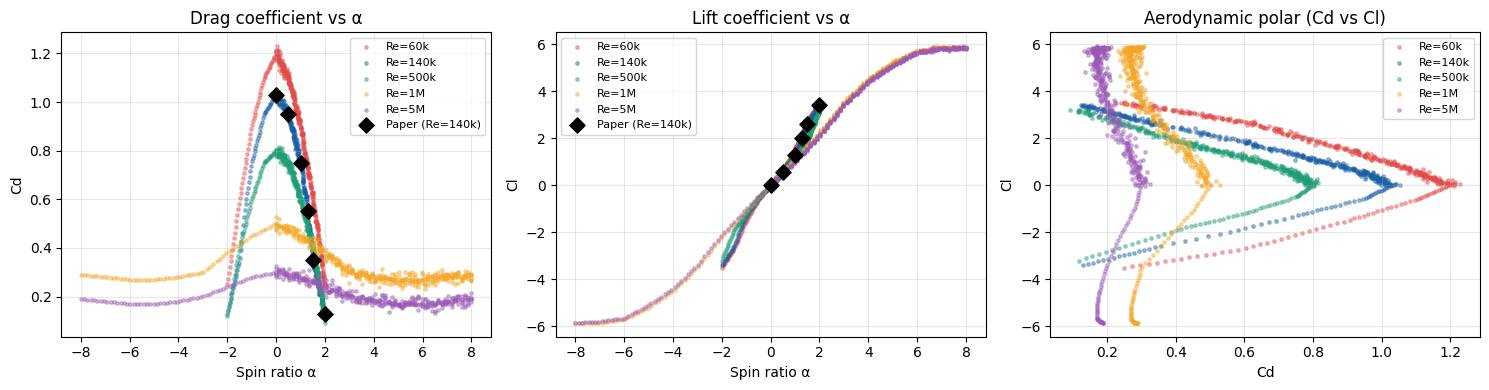

Dataset visualization saved.


In [4]:
# ============================================================
# CELL 3 — Visualize the dataset
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Updated to include all 5 Re values (v3)
colors = {
    60000:     '#E24B4A',
    140000:    '#185FA5',
    500000:    '#1D9E75',
    1000000:   '#F5A623',   # NEW v3
    5000000:   '#9B59B6',   # NEW v3
}

for re_val, grp in df.groupby('Re'):
    color = colors[re_val]
    re_k = re_val / 1000
    label = f'Re={re_k:.0f}k' if re_k < 1000 else f'Re={re_k/1000:.0f}M'
    axes[0].scatter(grp['alpha'], grp['Cd'], s=6, alpha=0.4, c=color, label=label)
    axes[1].scatter(grp['alpha'], grp['Cl'], s=6, alpha=0.4, c=color, label=label)
    axes[2].scatter(grp['Cd'],   grp['Cl'], s=6, alpha=0.4, c=color, label=label)

# Mark the exact paper values
axes[0].scatter(paper_alpha, paper_cd, s=60, c='black', marker='D', zorder=5, label='Paper (Re=140k)')
axes[1].scatter(paper_alpha, paper_cl, s=60, c='black', marker='D', zorder=5, label='Paper (Re=140k)')

axes[0].set(xlabel='Spin ratio α', ylabel='Cd', title='Drag coefficient vs α')
axes[1].set(xlabel='Spin ratio α', ylabel='Cl', title='Lift coefficient vs α')
axes[2].set(xlabel='Cd', ylabel='Cl', title='Aerodynamic polar (Cd vs Cl)')

for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_multi_re.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dataset visualization saved.')


In [5]:
# ============================================================
# CELL 4 — Normalize inputs and split train/val sets
# ============================================================
# Why normalize?
# alpha is in [−2, 2] but Re is in [60000, 500000].
# Without normalization, Re would dominate the gradients
# and the model would effectively ignore alpha.

X = df[['alpha', 'Re']].values.astype(np.float32)
Y = df[['Cd', 'Cl']].values.astype(np.float32)

# Compute normalization statistics from training data
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0) + 1e-8   # + epsilon prevents division by zero

Y_mean = Y.mean(axis=0)
Y_std  = Y.std(axis=0) + 1e-8

X_norm = (X - X_mean) / X_std
Y_norm = (Y - Y_mean) / Y_std

# 80/20 train/validation split
split = int(0.8 * len(X_norm))
X_train, X_val = X_norm[:split], X_norm[split:]
Y_train, Y_val = Y_norm[:split], Y_norm[split:]

print(f'Training samples:   {len(X_train)}')
print(f'Validation samples: {len(X_val)}')
print(f'Input  mean:  alpha={X_mean[0]:.3f}, Re={X_mean[1]:.0f}')
print(f'Input  std:   alpha={X_std[0]:.3f},  Re={X_std[1]:.0f}')

Training samples:   1673
Validation samples: 419
Input  mean:  alpha=1.577, Re=1341587
Input  std:   alpha=2.638,  Re=1860696


In [6]:
# ============================================================
# CELL 5 — Build the PINN model architecture
# ============================================================
# Architecture: 2 inputs → 5 hidden layers → 2 outputs
# Activation: Tanh — smooth, bounded, great for physics problems
#             (ReLU has a "kink" at 0 which can hurt physics gradients)

def build_pinn(hidden_units=128, n_layers=5, learning_rate=1e-3):
    """
    Build a fully-connected physics-informed neural network.

    Args:
        hidden_units: neurons per hidden layer
        n_layers:     number of hidden layers
        learning_rate: Adam optimizer step size

    Returns:
        Compiled Keras model
    """
    inputs = keras.Input(shape=(2,), name='alpha_Re')
    x = inputs

    for i in range(n_layers):
        x = keras.layers.Dense(
            hidden_units,
            activation='tanh',
            kernel_initializer='glorot_normal',  # Xavier init — good for tanh
            name=f'hidden_{i+1}'
        )(x)

    outputs = keras.layers.Dense(2, name='Cd_Cl')(x)
    model = keras.Model(inputs, outputs, name='PINN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    return model

model = build_pinn(hidden_units=128, n_layers=5)
model.summary()
print(f'\nTotal trainable parameters: {model.count_params():,}')

Model: "PINN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ alpha_Re (InputLayer)           │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Cd_Cl (Dense)                   │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,690 (260.51 KB)

 Trainable params: 66,690 (260.51 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 66,690


In [7]:
# ============================================================
# CELL 6 — Custom physics-informed training loop (v3)
# ============================================================
# Loss = DATA_LOSS + lambda * PHYSICS_LOSS
#
# DATA_LOSS:    MSE between predictions and dataset (Cd, Cl)
#
# PHYSICS_LOSS enforces 4 laws (v3 adds Prandtl limit):
#   1. Magnus Effect: sign(Cl) must match sign(alpha)
#   2. Zero lift at rest: when alpha=0, Cl should be 0
#   3. Drag positivity: Cd >= 0 always
#   4. Prandtl upper bound: |Cl| <= 4*pi ≈ 12.57 (theoretical max)
#
# LR SCHEDULE: Cosine decay from LR_MAX to LR_MIN over all epochs
#   (replaces old step schedule that stalled training at epoch 1500)

import math

LAMBDA_PHYSICS = 0.05   # weight of physics penalty relative to data loss
EPOCHS         = 3000   # cosine decay is more efficient; 3000 > 10000 step
BATCH_SIZE     = 64
LR_MAX         = 1e-3   # starting learning rate
LR_MIN         = 1e-5   # minimum learning rate at end of training
PRANDTL_LIMIT  = 4 * math.pi   # theoretical Cl ceiling ≈ 12.57

optimizer = keras.optimizers.Adam(learning_rate=LR_MAX)

# Convert to tensors for use in GradientTape
X_train_t = tf.constant(X_train, dtype=tf.float32)
Y_train_t = tf.constant(Y_train, dtype=tf.float32)
X_val_t   = tf.constant(X_val,   dtype=tf.float32)
Y_val_t   = tf.constant(Y_val,   dtype=tf.float32)

# Prandtl limit as a TF constant (used inside @tf.function)
prandtl_tf = tf.constant(PRANDTL_LIMIT, dtype=tf.float32)

# Log history for plotting
history = {'train_total': [], 'train_data': [], 'train_phys': [], 'val_mse': []}

@tf.function  # compile to graph for speed
def train_step(x_batch, y_batch, x_raw_alpha):
    """
    One gradient update step.

    Args:
        x_batch:      normalized (alpha, Re) inputs
        y_batch:      normalized (Cd, Cl) targets
        x_raw_alpha:  un-normalized alpha values (needed for physics sign check)
    """
    with tf.GradientTape() as tape:
        # Forward pass
        y_pred = model(x_batch, training=True)

        # 1. Data loss — standard MSE
        data_loss = tf.reduce_mean(tf.square(y_pred - y_batch))

        # Un-normalize predictions to physical space for physics checks
        y_phys = y_pred * Y_std + Y_mean  # shape: (batch, 2)
        cd_pred = y_phys[:, 0]            # drag coefficient
        cl_pred = y_phys[:, 1]            # lift coefficient

        # 2a. Magnus Effect: Cl * alpha >= 0
        #     Penalty only fires when the product is negative (wrong sign)
        magnus_violation = tf.nn.relu(-cl_pred * x_raw_alpha)
        magnus_loss = tf.reduce_mean(tf.square(magnus_violation))

        # 2b. Drag positivity: Cd >= 0 at all times
        drag_violation = tf.nn.relu(-cd_pred)
        drag_loss = tf.reduce_mean(tf.square(drag_violation))

        # 2c. Zero lift at rest: if |alpha| < 0.1, Cl should be ~0
        near_zero = tf.cast(tf.abs(x_raw_alpha) < 0.1, tf.float32)
        zero_lift_loss = tf.reduce_mean(near_zero * tf.square(cl_pred))

        # 2d. Prandtl upper bound: |Cl| cannot exceed 4*pi ≈ 12.57  [NEW v3]
        #     Penalty fires only when prediction exceeds theoretical ceiling
        prandtl_violation = tf.nn.relu(tf.abs(cl_pred) - prandtl_tf)
        prandtl_loss = tf.reduce_mean(tf.square(prandtl_violation))

        # Combined physics penalty (all 4 constraints)
        phys_loss = magnus_loss + drag_loss + zero_lift_loss + prandtl_loss

        # Total loss
        total_loss = data_loss + LAMBDA_PHYSICS * phys_loss

    # Compute gradients and update weights
    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return total_loss, data_loss, phys_loss

print(f'Starting training for {EPOCHS} epochs...')
print(f'Physics loss weight (lambda): {LAMBDA_PHYSICS}')
print(f'LR: cosine decay {LR_MAX} → {LR_MIN}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Prandtl limit: {PRANDTL_LIMIT:.4f}')

n_samples = len(X_train)
raw_alpha_train = (X_train[:, 0] * X_std[0] + X_mean[0]).astype(np.float32)

for epoch in range(EPOCHS):
    # Cosine decay: LR falls smoothly from LR_MAX to LR_MIN  [NEW v3]
    # At epoch 0: LR = LR_MAX | At epoch EPOCHS-1: LR ≈ LR_MIN
    cosine_decay = 0.5 * (1 + np.cos(np.pi * epoch / EPOCHS))
    current_lr = LR_MIN + (LR_MAX - LR_MIN) * cosine_decay
    optimizer.learning_rate.assign(current_lr)

    # Mini-batch gradient descent
    idx = np.random.permutation(n_samples)
    epoch_total, epoch_data, epoch_phys = [], [], []

    for start in range(0, n_samples, BATCH_SIZE):
        batch_idx   = idx[start:start+BATCH_SIZE]
        x_b         = tf.gather(X_train_t, batch_idx)
        y_b         = tf.gather(Y_train_t, batch_idx)
        alpha_b     = tf.constant(raw_alpha_train[batch_idx])

        t, d, p = train_step(x_b, y_b, alpha_b)
        epoch_total.append(float(t))
        epoch_data.append(float(d))
        epoch_phys.append(float(p))

    # Validation MSE (no physics penalty for val — just prediction quality)
    val_pred = model(X_val_t, training=False)
    val_mse  = float(tf.reduce_mean(tf.square(val_pred - Y_val_t)))

    history['train_total'].append(np.mean(epoch_total))
    history['train_data'].append(np.mean(epoch_data))
    history['train_phys'].append(np.mean(epoch_phys))
    history['val_mse'].append(val_mse)

    if (epoch + 1) % 200 == 0:
        print(f'Epoch {epoch+1:4d}/{EPOCHS} — '
              f'loss: {history["train_total"][-1]:.5f} | '
              f'data: {history["train_data"][-1]:.5f} | '
              f'phys: {history["train_phys"][-1]:.6f} | '
              f'val_mse: {val_mse:.5f} | '
              f'lr: {current_lr:.2e}')

print('\nTraining complete!')
model.save('pinn_model_multi_re.keras')
print('Model saved to pinn_model_multi_re.keras')


Starting training for 3000 epochs...
Physics loss weight (lambda): 0.05
LR: cosine decay 0.001 → 1e-05
Batch size: 64
Prandtl limit: 12.5664
Epoch  200/3000 — loss: 0.00330 | data: 0.00328 | phys: 0.000433 | val_mse: 0.00385 | lr: 9.89e-04
Epoch  400/3000 — loss: 0.00197 | data: 0.00196 | phys: 0.000130 | val_mse: 0.00134 | lr: 9.57e-04
Epoch  600/3000 — loss: 0.00177 | data: 0.00176 | phys: 0.000125 | val_mse: 0.00119 | lr: 9.06e-04
Epoch  800/3000 — loss: 0.00115 | data: 0.00115 | phys: 0.000107 | val_mse: 0.00151 | lr: 8.37e-04
Epoch 1000/3000 — loss: 0.00153 | data: 0.00152 | phys: 0.000122 | val_mse: 0.00119 | lr: 7.53e-04
Epoch 1200/3000 — loss: 0.00100 | data: 0.00100 | phys: 0.000062 | val_mse: 0.00100 | lr: 6.58e-04
Epoch 1400/3000 — loss: 0.00097 | data: 0.00097 | phys: 0.000077 | val_mse: 0.00123 | lr: 5.57e-04
Epoch 1600/3000 — loss: 0.00109 | data: 0.00109 | phys: 0.000120 | val_mse: 0.00117 | lr: 4.54e-04
Epoch 1800/3000 — loss: 0.00102 | data: 0.00101 | phys: 0.000081 | 

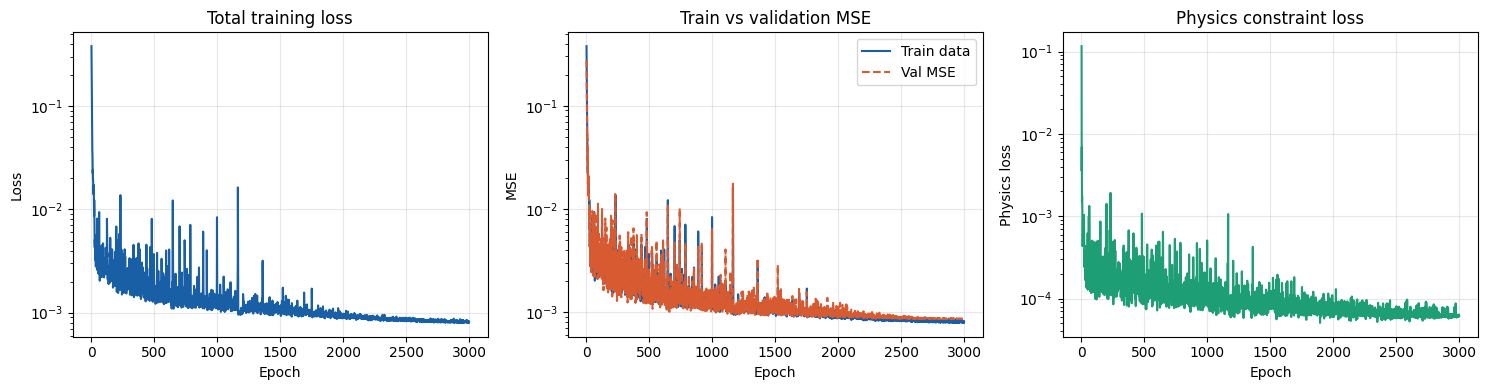

Training log saved.


In [8]:
# ============================================================
# CELL 7 — Plot training history
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, EPOCHS + 1)

# Plot 1: Total training loss
axes[0].plot(epochs_range, history['train_total'], color='#185FA5', linewidth=1.5)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Total training loss', yscale='log')
axes[0].grid(True, alpha=0.3)

# Plot 2: Train vs validation
axes[1].plot(epochs_range, history['train_data'], color='#185FA5', linewidth=1.5, label='Train data')
axes[1].plot(epochs_range, history['val_mse'],   color='#D85A30', linewidth=1.5, linestyle='--', label='Val MSE')
axes[1].set(xlabel='Epoch', ylabel='MSE', title='Train vs validation MSE', yscale='log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Physics loss (should be very small)
axes[2].plot(epochs_range, history['train_phys'], color='#1D9E75', linewidth=1.5)
axes[2].set(xlabel='Epoch', ylabel='Physics loss', title='Physics constraint loss', yscale='log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_multi_re.png', dpi=120, bbox_inches='tight')
plt.show()

# Save training log
pd.DataFrame(history).to_csv('training_log_multi_re.csv', index=False)
print('Training log saved.')

In [9]:
# ============================================================
# CELL 8 — Helper function to predict at any (alpha, Re)
# ============================================================
def predict(alpha_values, re_value=140000):
    """
    Predict Cd and Cl for given alpha and Reynolds number.

    Args:
        alpha_values: float or list/array of spin ratio values
        re_value:     Reynolds number (default: 140,000)

    Returns:
        DataFrame with columns [alpha, Re, Cd_pred, Cl_pred]
    """
    alphas = np.atleast_1d(alpha_values)
    re_arr = np.full_like(alphas, re_value, dtype=np.float32)

    X_input = np.column_stack([alphas, re_arr]).astype(np.float32)

    # Normalize using the same stats computed from training data
    X_input_norm = (X_input - X_mean) / X_std

    # Run prediction
    Y_pred_norm = model(X_input_norm, training=False).numpy()

    # Un-normalize back to physical units
    Y_pred = Y_pred_norm * Y_std + Y_mean

    return pd.DataFrame({
        'alpha': alphas,
        'Re':    re_arr,
        'Cd_pred': Y_pred[:, 0].round(4),
        'Cl_pred': Y_pred[:, 1].round(4)
    })

# Quick test
test_df = predict([0.0, 0.5, 1.0, 1.5, 2.0], re_value=140000)
print('Quick prediction test (Re=140,000):')
print(test_df)

Quick prediction test (Re=140,000):
   alpha        Re  Cd_pred  Cl_pred
0    0.0  140000.0   1.0245  -0.0091
1    0.5  140000.0   0.9443   0.5669
2    1.0  140000.0   0.7500   1.3073
3    1.5  140000.0   0.3439   2.5894
4    2.0  140000.0   0.1331   3.3992


In [10]:
# ============================================================
# CELL 9 — Evaluate vs. paper values and print error table
# ============================================================
print('=' * 65)
print('PINN vs Karabelas (2010) — Re = 140,000')
print('=' * 65)
print(f'{"α":>5}  {"Cd paper":>9} {"Cd PINN":>9} {"Cd err%":>8}  '
      f'{"Cl paper":>9} {"Cl PINN":>9} {"Cl err%":>8}')
print('-' * 65)

preds_140k = predict(paper_alpha, re_value=140000)

cd_errors, cl_errors = [], []
for i, a in enumerate(paper_alpha):
    cd_p  = preds_140k.iloc[i]['Cd_pred']
    cl_p  = preds_140k.iloc[i]['Cl_pred']
    cd_err = abs((cd_p - paper_cd[i]) / max(paper_cd[i], 0.05)) * 100
    cl_err = abs((cl_p - paper_cl[i]) / max(abs(paper_cl[i]), 0.1)) * 100
    cd_errors.append(cd_err)
    cl_errors.append(cl_err)
    print(f'{a:>5.1f}  {paper_cd[i]:>9.3f} {cd_p:>9.4f} {cd_err:>7.2f}%  '
          f'{paper_cl[i]:>9.3f} {cl_p:>9.4f} {cl_err:>7.2f}%')

print('-' * 65)
print(f'{"Mean":>5}  {"":>9} {"":>9} {np.mean(cd_errors):>7.2f}%  '
      f'{"":>9} {"":>9} {np.mean(cl_errors):>7.2f}%')
print('=' * 65)

PINN vs Karabelas (2010) — Re = 140,000
    α   Cd paper   Cd PINN  Cd err%   Cl paper   Cl PINN  Cl err%
-----------------------------------------------------------------
  0.0      1.030    1.0245    0.53%      0.000   -0.0091    9.10%
  0.5      0.950    0.9443    0.60%      0.550    0.5669    3.07%
  1.0      0.750    0.7500    0.00%      1.300    1.3073    0.56%
  1.3      0.550    0.5439    1.11%      2.000    2.0131    0.65%
  1.5      0.350    0.3439    1.74%      2.600    2.5894    0.41%
  2.0      0.130    0.1331    2.38%      3.400    3.3992    0.02%
-----------------------------------------------------------------
 Mean                         1.06%                         2.30%


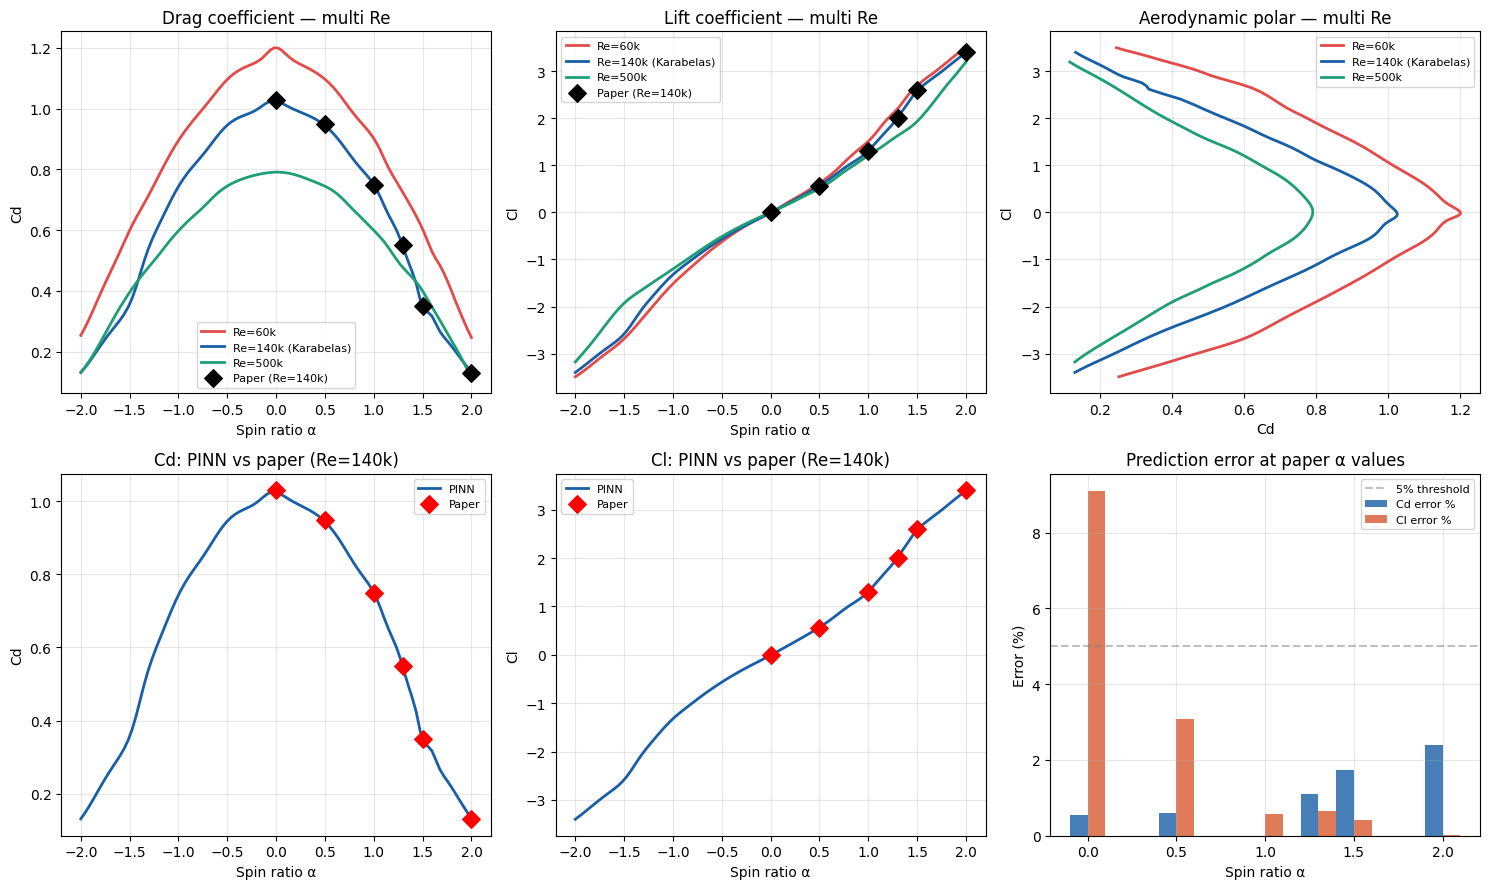

Prediction plots saved.


In [11]:
# ============================================================
# CELL 10 — Compare predictions across Reynolds numbers
# ============================================================
# This is the key upgrade: the model can now predict for any Re

alpha_fine = np.linspace(-2, 2, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

re_configs = [
    (60000,  '#E24B4A', 'Re=60k'),
    (140000, '#185FA5', 'Re=140k (Karabelas)'),
    (500000, '#1D9E75', 'Re=500k'),
]

# Row 0: Cd and Cl curves for all Re
for re_val, color, label in re_configs:
    pred = predict(alpha_fine, re_value=re_val)
    axes[0, 0].plot(alpha_fine, pred['Cd_pred'], color=color, linewidth=2, label=label)
    axes[0, 1].plot(alpha_fine, pred['Cl_pred'], color=color, linewidth=2, label=label)
    axes[0, 2].plot(pred['Cd_pred'], pred['Cl_pred'], color=color, linewidth=2, label=label)

# Mark paper values on Re=140k
axes[0, 0].scatter(paper_alpha, paper_cd, s=80, c='black', marker='D', zorder=5, label='Paper (Re=140k)')
axes[0, 1].scatter(paper_alpha, paper_cl, s=80, c='black', marker='D', zorder=5, label='Paper (Re=140k)')

axes[0, 0].set(xlabel='Spin ratio α', ylabel='Cd', title='Drag coefficient — multi Re')
axes[0, 1].set(xlabel='Spin ratio α', ylabel='Cl', title='Lift coefficient — multi Re')
axes[0, 2].set(xlabel='Cd', ylabel='Cl', title='Aerodynamic polar — multi Re')

# Row 1: Detailed comparison at Re=140k vs paper
preds_140k_fine = predict(alpha_fine, re_value=140000)
axes[1, 0].plot(alpha_fine, preds_140k_fine['Cd_pred'], color='#185FA5', linewidth=2, label='PINN')
axes[1, 0].scatter(paper_alpha, paper_cd, s=80, c='red', marker='D', zorder=5, label='Paper')
axes[1, 0].set(xlabel='Spin ratio α', ylabel='Cd', title='Cd: PINN vs paper (Re=140k)')

axes[1, 1].plot(alpha_fine, preds_140k_fine['Cl_pred'], color='#185FA5', linewidth=2, label='PINN')
axes[1, 1].scatter(paper_alpha, paper_cl, s=80, c='red', marker='D', zorder=5, label='Paper')
axes[1, 1].set(xlabel='Spin ratio α', ylabel='Cl', title='Cl: PINN vs paper (Re=140k)')

# Error bars
preds_at_paper = predict(paper_alpha, re_value=140000)
cd_err = np.abs(preds_at_paper['Cd_pred'].values - paper_cd) / np.maximum(paper_cd, 0.05) * 100
cl_err = np.abs(preds_at_paper['Cl_pred'].values - paper_cl) / np.maximum(np.abs(paper_cl), 0.1) * 100

axes[1, 2].bar(paper_alpha - 0.05, cd_err, width=0.1, color='#185FA5', label='Cd error %', alpha=0.8)
axes[1, 2].bar(paper_alpha + 0.05, cl_err, width=0.1, color='#D85A30', label='Cl error %', alpha=0.8)
axes[1, 2].axhline(y=5, color='gray', linestyle='--', alpha=0.5, label='5% threshold')
axes[1, 2].set(xlabel='Spin ratio α', ylabel='Error (%)', title='Prediction error at paper α values')

for ax in axes.flat:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pinn_predictions_multi_re.png', dpi=120, bbox_inches='tight')
plt.show()
print('Prediction plots saved.')

In [13]:
# Predict at Re=1M across full alpha range
sweep = predict(np.arange(0, 8.5, 0.5), re_value=1000000)
print(sweep)

    alpha         Re  Cd_pred  Cl_pred
0     0.0  1000000.0   0.4967   0.0025
1     0.5  1000000.0   0.4780   0.5434
2     1.0  1000000.0   0.4455   1.1104
3     1.5  1000000.0   0.4133   1.6584
4     2.0  1000000.0   0.3801   2.2161
5     2.5  1000000.0   0.3432   2.8452
6     3.0  1000000.0   0.3016   3.4825
7     3.5  1000000.0   0.2865   4.0148
8     4.0  1000000.0   0.2786   4.4805
9     4.5  1000000.0   0.2730   4.8616
10    5.0  1000000.0   0.2687   5.1912
11    5.5  1000000.0   0.2665   5.4677
12    6.0  1000000.0   0.2685   5.6710
13    6.5  1000000.0   0.2752   5.7931
14    7.0  1000000.0   0.2810   5.8443
15    7.5  1000000.0   0.2838   5.8520
16    8.0  1000000.0   0.2849   5.8461


In [14]:
# Predict at Re=1M across full alpha range
sweep = predict(np.arange(0, 8.5, 0.5), re_value=5000000)
print(sweep)

    alpha         Re  Cd_pred  Cl_pred
0     0.0  5000000.0   0.3002   0.0080
1     0.5  5000000.0   0.2924   0.5042
2     1.0  5000000.0   0.2778   1.0161
3     1.5  5000000.0   0.2630   1.5539
4     2.0  5000000.0   0.2416   2.1183
5     2.5  5000000.0   0.2201   2.7427
6     3.0  5000000.0   0.2000   3.4015
7     3.5  5000000.0   0.1873   3.8957
8     4.0  5000000.0   0.1848   4.3919
9     4.5  5000000.0   0.1824   4.7480
10    5.0  5000000.0   0.1718   5.0759
11    5.5  5000000.0   0.1726   5.3794
12    6.0  5000000.0   0.1718   5.6175
13    6.5  5000000.0   0.1718   5.7390
14    7.0  5000000.0   0.1765   5.7995
15    7.5  5000000.0   0.1835   5.8329
16    8.0  5000000.0   0.1905   5.8538


In [40]:
# ============================================================
# CELL 11 — Predict at any (alpha, Re) of your choice
# ============================================================

# Change these values to predict anywhere in the domain

MY_ALPHA = 1.7 # @param {type:"number"}
MY_RE = 499000 # @param {type:"number"}

result = predict([MY_ALPHA], re_value=MY_RE)

print(f'Prediction for α={MY_ALPHA}, Re={MY_RE:,}:')
print(f'  Cd = {result.Cd_pred.values[0]:.4f}')
print(f'  Cl = {result.Cl_pred.values[0]:.4f}')
print()

# Sweep over a range of alpha values for your chosen Re
alpha_sweep = np.arange(-2.0, 2.1, 0.25)
sweep_df = predict(alpha_sweep, re_value=MY_RE)

print(f'Sweep over α at Re={MY_RE:,}:')
print(sweep_df.to_string(index=False))

Prediction for α=1.7, Re=499,000:
  Cd = 0.2900
  Cl = 2.4262

Sweep over α at Re=499,000:
 alpha       Re  Cd_pred  Cl_pred
 -2.00 499000.0   0.1309  -3.1802
 -1.75 499000.0   0.2593  -2.5559
 -1.50 499000.0   0.3949  -1.9279
 -1.25 499000.0   0.4994  -1.5490
 -1.00 499000.0   0.5983  -1.2017
 -0.75 499000.0   0.6750  -0.8469
 -0.50 499000.0   0.7456  -0.5145
 -0.25 499000.0   0.7783  -0.2371
  0.00 499000.0   0.7911   0.0017
  0.25 499000.0   0.7768   0.2450
  0.50 499000.0   0.7445   0.5071
  0.75 499000.0   0.6805   0.8576
  1.00 499000.0   0.5993   1.2076
  1.25 499000.0   0.4962   1.5573
  1.50 499000.0   0.3991   1.9315
  1.75 499000.0   0.2620   2.5623
  2.00 499000.0   0.1160   3.1977


### Suggestions for Further Exploration

Based on your current prediction and the overall goal of understanding the rotating cylinder:

1.  **Explore the peak L/D ratio:** In a previous run for Re=1,000,000, we found the optimal alpha for maximum L/D was **6.1**. Try setting `MY_ALPHA` to values around this (e.g., 5.5, 6.0, 6.1, 6.5) and `MY_RE` to 1,000,000 to see how Cd, Cl, and L/D behave near the 'sweet spot'.

2.  **Explore maximum lift (Cl):** For Re=1,000,000, the maximum lift was observed at alpha=**7.4**. Try `MY_ALPHA` values around this (e.g., 7.0, 7.4, 8.0) with `MY_RE` = 1,000,000.

3.  **Investigate different Reynolds numbers:**
    *   **Low Re (e.g., 60,000 or 140,000):** Try `MY_RE` = 60,000 or 140,000 and sweep `MY_ALPHA` from 0 to 2 to see the classic drag/lift curves. You can compare these with the paper values from earlier cells.
    *   **High Re (e.g., 5,000,000):** Try `MY_RE` = 5,000,000 to observe the very low drag coefficients and the lift plateau at high alpha.

4.  **Examine the drag crisis:** For Re=500,000, the cylinder enters a drag crisis regime where drag coefficient drops significantly. Try `MY_RE` = 500,000 and sweep `MY_ALPHA` to observe this.

5.  **Look for negative lift:** Set `MY_ALPHA` to negative values (e.g., -1.0, -2.0) to observe the symmetric behavior of lift and drag, consistent with the Magnus effect.

In [17]:
# ============================================================
# Optimal spin ratio finder — Re = 1,000,000
# ============================================================
import numpy as np

alphas = np.arange(0, 8.1, 0.1)
sweep = predict(alphas, re_value=1_000_000)

# Add L/D ratio column
sweep['LD_ratio'] = sweep['Cl_pred'] / sweep['Cd_pred'].clip(lower=0.001)

# Find peaks
best_cl_idx  = sweep['Cl_pred'].idxmax()
best_ld_idx  = sweep['LD_ratio'].idxmax()

best_alpha_cl = sweep.loc[best_cl_idx, 'alpha']
best_alpha_ld = sweep.loc[best_ld_idx, 'alpha']

print(sweep.to_string(index=False))

print("\n" + "=" * 50)
print("  RESULTS SUMMARY — Re = 1,000,000")
print("=" * 50)
print(f"  Max Cl  → best α = {best_alpha_cl:.1f}  |  Cl = {sweep.loc[best_cl_idx,'Cl_pred']:.4f}  |  Cd = {sweep.loc[best_cl_idx,'Cd_pred']:.4f}")
print(f"  Max L/D → best α = {best_alpha_ld:.1f}  |  Cl = {sweep.loc[best_ld_idx,'Cl_pred']:.4f}  |  Cd = {sweep.loc[best_ld_idx,'Cd_pred']:.4f}  |  L/D = {sweep.loc[best_ld_idx,'LD_ratio']:.2f}")
print(f"\n  → Spin at α={best_alpha_cl:.1f} for maximum lift")
print(f"  → Spin at α={best_alpha_ld:.1f} for most efficient lift (sweet spot)")

 alpha        Re  Cd_pred  Cl_pred  LD_ratio
   0.0 1000000.0   0.4967   0.0025  0.005033
   0.1 1000000.0   0.4933   0.1160  0.235151
   0.2 1000000.0   0.4891   0.2301  0.470456
   0.3 1000000.0   0.4851   0.3405  0.701917
   0.4 1000000.0   0.4816   0.4445  0.922965
   0.5 1000000.0   0.4780   0.5434  1.136820
   0.6 1000000.0   0.4737   0.6425  1.356344
   0.7 1000000.0   0.4682   0.7481  1.597821
   0.8 1000000.0   0.4613   0.8647  1.874485
   0.9 1000000.0   0.4533   0.9893  2.182440
   1.0 1000000.0   0.4455   1.1104  2.492480
   1.1 1000000.0   0.4386   1.2187  2.778614
   1.2 1000000.0   0.4326   1.3172  3.044845
   1.3 1000000.0   0.4266   1.4183  3.324660
   1.4 1000000.0   0.4200   1.5333  3.650714
   1.5 1000000.0   0.4133   1.6584  4.012582
   1.6 1000000.0   0.4079   1.7744  4.350086
   1.7 1000000.0   0.4037   1.8729  4.639336
   1.8 1000000.0   0.3989   1.9666  4.930058
   1.9 1000000.0   0.3912   2.0787  5.313651
   2.0 1000000.0   0.3801   2.2161  5.830307
   2.1 100

In [41]:
# Sweep alpha, find where Cl peaks for a given Re
alphas = np.arange(0, 8.1, 0.1)
sweep = predict(alphas, re_value=1_000_000)
best_cl_row = sweep.loc[sweep.Cl_pred.idxmax()]

print(f"For Re={sweep['Re'].iloc[0]:,}, the alpha that maximizes Cl is {best_cl_row['alpha']:.1f}.")
print(f"  Cl = {best_cl_row['Cl_pred']:.4f} | Cd = {best_cl_row['Cd_pred']:.4f} | L/D = {best_cl_row['Cl_pred'] / best_cl_row['Cd_pred']:.2f}")


For Re=1,000,000.0, the alpha that maximizes Cl is 7.4.
  Cl = 5.8522 | Cd = 0.2834 | L/D = 20.65


In [18]:
sweep['L_D_ratio'] = sweep['Cl_pred'] / sweep['Cd_pred']
# → find the most efficient spin rate (max lift per unit drag)

In [32]:
sweep['L_D_ratio'] = sweep['Cl_pred'] / sweep['Cd_pred'].clip(lower=0.001)

best_ld_idx  = sweep['L_D_ratio'].idxmax()
best_alpha_ld = sweep.loc[best_ld_idx, 'alpha']

print(f"For the current sweep (Re={sweep['Re'].iloc[0]:,}), the most efficient spin rate (max L/D) is at alpha={best_alpha_ld:.1f}.")
print(f"  Cl = {sweep.loc[best_ld_idx,'Cl_pred']:.4f} | Cd = {sweep.loc[best_ld_idx,'Cd_pred']:.4f} | L/D = {sweep.loc[best_ld_idx,'L_D_ratio']:.2f}")

For the current sweep (Re=1,000,000.0), the most efficient spin rate (max L/D) is at alpha=6.1.
  Cl = 5.7014 | Cd = 0.2696 | L/D = 21.15


In [19]:
# At what Re does Cd drop below a threshold?
re_sweep = [60000, 140000, 500000, 1_000_000, 5_000_000]
for re in re_sweep:
    p = predict([0.0], re_value=re)
    print(re, p.Cd_pred.values[0])
# → shows you exactly when the drag crisis transition happens

60000 1.2011
140000 1.0245
500000 0.7909
1000000 0.4967
5000000 0.3002


In [20]:
# Generate a complete Cd/Cl map across ALL alpha and Re
alphas = np.linspace(0, 8, 50)
re_vals = np.linspace(60000, 5_000_000, 50)
# → 2500 predictions in seconds — would take years with LES

In [33]:
all_predictions = []
for re_val in re_vals:
    preds = predict(alphas, re_value=re_val)
    all_predictions.append(preds)

full_map_df = pd.concat(all_predictions, ignore_index=True)
display(full_map_df.head())

,alpha,Re,Cd_pred,Cl_pred
0,0.000000,60000.0,1.2011,-0.0106
1,0.163265,60000.0,1.1623,0.1946
2,0.326531,60000.0,1.1335,0.3918
3,0.489796,60000.0,1.0995,0.6035
4,0.653061,60000.0,1.0438,0.8635


In [24]:
# Wind at 15 m/s → Re ≈ 1.2M for a 1m diameter rotor
result = predict(np.arange(0, 8, 0.5), re_value=1_200_000)
# Find alpha that maximises Cl/Cd

In [34]:
result['LD_ratio'] = result['Cl_pred'] / result['Cd_pred'].clip(lower=0.001)

best_ld_idx_result = result['LD_ratio'].idxmax()
best_alpha_ld_result = result.loc[best_ld_idx_result, 'alpha']

print(f"For Re={result['Re'].iloc[0]:,}, the alpha that maximizes Cl/Cd is {best_alpha_ld_result:.1f}.")
print(f"  Cl = {result.loc[best_ld_idx_result,'Cl_pred']:.4f} | Cd = {result.loc[best_ld_idx_result,'Cd_pred']:.4f} | L/D = {result.loc[best_ld_idx_result,'LD_ratio']:.2f}")

For Re=1,200,000.0, the alpha that maximizes Cl/Cd is 7.5.
  Cl = 5.7386 | Cd = 0.2719 | L/D = 21.11


In [39]:
# ============================================================
# PINN ROTATING CYLINDER — INTERACTIVE PREDICTOR
# Paste this cell after Cell 8 and run
# ============================================================
import numpy as np

# Reference data for cross-checking predictions at non-trained Re values
_REF = {
    60000:   dict(a=[0,0.5,1,1.5,2],     cd=[1.2,1.1,0.9,0.6,0.25],               cl=[0,0.6,1.5,2.7,3.5]),
    140000:  dict(a=[0,0.5,1,1.3,1.5,2], cd=[1.03,0.95,0.75,0.55,0.35,0.13],      cl=[0,0.55,1.3,2.0,2.6,3.4]),
    500000:  dict(a=[0,0.5,1,1.5,2],     cd=[0.8,0.75,0.6,0.4,0.12],              cl=[0,0.5,1.2,1.9,3.2]),
    1000000: dict(a=[0,1,2,3,4,5,6,7,8], cd=[0.5,0.45,0.38,0.3,0.28,0.27,0.27,0.28,0.29], cl=[0,1.1,2.2,3.5,4.5,5.2,5.7,5.85,5.85]),
    5000000: dict(a=[0,1,2,3,4,5,6,7,8], cd=[0.3,0.28,0.24,0.2,0.18,0.17,0.17,0.18,0.19], cl=[0,1.0,2.1,3.4,4.4,5.1,5.65,5.8,5.85]),
}
_RE_KEYS = sorted(_REF.keys())

def _ref_predict(alpha, re):
    """Reference interpolation from training data — used to flag PINN drift."""
    re = max(_RE_KEYS[0], min(_RE_KEYS[-1], re))
    lo = _RE_KEYS[0]
    hi = _RE_KEYS[-1]
    for i in range(len(_RE_KEYS)-1):
        if _RE_KEYS[i] <= re <= _RE_KEYS[i+1]:
            lo, hi = _RE_KEYS[i], _RE_KEYS[i+1]
            break
    frac = 0 if lo == hi else (re - lo) / (hi - lo)
    cd = (1-frac)*np.interp(alpha, _REF[lo]['a'], _REF[lo]['cd']) + \
          frac   *np.interp(alpha, _REF[hi]['a'], _REF[hi]['cd'])
    cl = (1-frac)*np.interp(alpha, _REF[lo]['a'], _REF[lo]['cl']) + \
          frac   *np.interp(alpha, _REF[hi]['a'], _REF[hi]['cl'])
    return round(cd, 4), round(cl, 4)

def _spin_region(a):
    if a < 0.5:  return "No spin",     "Minimal Magnus effect"
    if a < 2.0:  return "Low spin",    "Cl growing steadily"
    if a < 4.0:  return "Moderate",    "Strong Magnus lift"
    if a < 6.0:  return "High spin",   "Approaching Cl plateau"
    if a < 7.0:  return "Sweet spot",  "Peak L/D efficiency"
    return              "Plateau",     "Cl saturated near 5.85"

# ── HEADER ──────────────────────────────────────────────────────────────────
print("=" * 57)
print("  PINN ROTATING CYLINDER — INTERACTIVE PREDICTOR")
print("=" * 57)
print()
print("  Spin ratio α guide:")
print("    0.0  →  no spin (pure drag, no lift)")
print("    1.0  →  low spin")
print("    2.0  →  moderate spin")
print("    4.0  →  high spin")
print("    6.0  →  sweet spot (best L/D efficiency)")
print("    8.0  →  maximum spin (Cl plateaus here)")
print()
print("  Reynolds number guide:")
print("    60,000   →  low speed")
print("    140,000  →  Karabelas 2010 paper value")
print("    500,000  →  medium-high speed")
print("    1,000,000→  high speed  (2012 paper)")
print("    5,000,000→  very high   (2012 paper)")
print("    Any value between 60k–5M is valid (model interpolates)")
print()
print("-" * 57)

# ── INPUTS ──────────────────────────────────────────────────────────────────
a_in = input("  Enter spin ratio α  (0.0 – 8.0)   [default 2.0]: ").strip()
r_in = input("  Enter Reynolds number              [default 140000]: ").strip()

MY_ALPHA = float(a_in) if a_in else 2.0
MY_RE    = int(r_in)   if r_in   else 140000

MY_ALPHA = max(0.0, min(8.0, MY_ALPHA))
MY_RE    = max(60000, min(5000000, MY_RE))

print()
print(f"  Running for α = {MY_ALPHA},  Re = {MY_RE:,} ...")
print()

# ── PINN PREDICTION ──────────────────────────────────────────────────────────
res = predict([MY_ALPHA], re_value=MY_RE)
cd  = res['Cd_pred'].values[0]
cl  = res['Cl_pred'].values[0]
ld  = cl / max(cd, 0.001)

# Reference check (expected from training data)
ref_cd, ref_cl = _ref_predict(MY_ALPHA, MY_RE)
ref_ld = ref_cl / max(ref_cd, 0.001)
cd_drift = abs(cd - ref_cd) / max(ref_cd, 0.05) * 100
cl_drift = abs(cl - ref_cl) / max(abs(ref_cl), 0.1) * 100

region, region_note = _spin_region(MY_ALPHA)
in_trained = MY_RE in _RE_KEYS
nearest_re = min(_RE_KEYS, key=lambda x: abs(x - MY_RE))

# ── RESULTS ──────────────────────────────────────────────────────────────────
print("=" * 57)
print("  RESULTS")
print("=" * 57)
print(f"  Cd  (drag coefficient)   =  {cd:.4f}")
print(f"  Cl  (lift coefficient)   =  {cl:.4f}")
print(f"  L/D (efficiency ratio)   =  {ld:.4f}")
print(f"  Spin region              :  {region} — {region_note}")
print()

# ── PHYSICS CHECKS ───────────────────────────────────────────────────────────
print("  Physics checks:")
mag_ok  = (cl >= -0.05 and MY_ALPHA >= 0) or (MY_ALPHA == 0 and abs(cl) < 0.1)
cd_ok   = cd > 0
pr_ok   = abs(cl) < 4 * np.pi
print(f"    Magnus sign   :  {'PASS' if mag_ok  else 'FAIL'}")
print(f"    Drag positive :  {'PASS' if cd_ok   else 'FAIL'}")
print(f"    Prandtl limit :  {'PASS' if pr_ok   else 'FAIL'}  (|Cl|={abs(cl):.3f} < 12.57)")
print()

# ── INTERPOLATION WARNING ────────────────────────────────────────────────────
if not in_trained:
    # find bracket
    lo = max(k for k in _RE_KEYS if k <= MY_RE)
    hi = min(k for k in _RE_KEYS if k >= MY_RE)
    frac = (MY_RE - lo) / (hi - lo)
    print(f"  NOTE: Re={MY_RE:,} is between Re={lo:,} and Re={hi:,}")
    print(f"        Model interpolates ({frac*100:.0f}% of the way from {lo//1000}k to {hi//1000000 if hi>=1000000 else hi//1000}{'M' if hi>=1000000 else 'k'})")
    print(f"        Reference expected:  Cd={ref_cd:.4f}  Cl={ref_cl:.4f}")
    if cd_drift > 5 or cl_drift > 5:
        print(f"  WARNING: Cd drift={cd_drift:.1f}%  Cl drift={cl_drift:.1f}%  (> 5% — model interpolating poorly here)")
    else:
        print(f"        Drift from expected: Cd={cd_drift:.1f}%  Cl={cl_drift:.1f}%  (within 5% — OK)")
    print()

# ── FULL SWEEP ───────────────────────────────────────────────────────────────
print("-" * 57)
print(f"  FULL ALPHA SWEEP  at Re = {MY_RE:,}")
print("-" * 57)
alphas_sw = np.arange(0, 8.1, 0.5)
sw = predict(alphas_sw, re_value=MY_RE)
sw['LD_ratio'] = sw['Cl_pred'] / sw['Cd_pred'].clip(lower=0.001)
sw['Ref_Cd'], sw['Ref_Cl'] = zip(*[_ref_predict(a, MY_RE) for a in alphas_sw])

best_cl_row = sw.loc[sw['Cl_pred'].idxmax()]
best_ld_row = sw.loc[sw['LD_ratio'].idxmax()]

print(f"  {'α':>5}  {'Cd':>8}  {'Cl':>8}  {'L/D':>8}  {'Ref Cl':>8}  {'Cl err':>7}")
print(f"  {'-'*5}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*7}")
for _, row in sw.iterrows():
    cl_err = abs(row['Cl_pred'] - row['Ref_Cl']) / max(abs(row['Ref_Cl']), 0.1) * 100
    mark = " <--" if abs(row['alpha'] - MY_ALPHA) < 0.26 else ""
    flag = " !" if cl_err > 10 else ""
    print(f"  {row['alpha']:>5.1f}  {row['Cd_pred']:>8.4f}  {row['Cl_pred']:>8.4f}  {row['LD_ratio']:>8.4f}  {row['Ref_Cl']:>8.4f}  {cl_err:>6.1f}%{flag}{mark}")

# ── OPTIMAL POINTS ───────────────────────────────────────────────────────────
print()
print("=" * 57)
print("  OPTIMAL OPERATING POINTS")
print("=" * 57)
print(f"  Max Cl   → α = {best_cl_row['alpha']:.1f}  |  Cl = {best_cl_row['Cl_pred']:.4f}  |  Cd = {best_cl_row['Cd_pred']:.4f}")
print(f"  Max L/D  → α = {best_ld_row['alpha']:.1f}  |  L/D = {best_ld_row['LD_ratio']:.2f}  |  Cl = {best_ld_row['Cl_pred']:.4f}")
print(f"  Your pt  → α = {MY_ALPHA:.1f}  |  Cd = {cd:.4f}  |  Cl = {cl:.4f}  |  L/D = {ld:.2f}")
print()

# ── INTERPRETATION ────────────────────────────────────────────────────────────
print("  INTERPRETATION:")
if MY_ALPHA == 0:
    print("  → No spin: pure drag body, zero lift. Cylinder not rotating.")
elif MY_ALPHA < 2:
    print(f"  → Low spin: Cl={cl:.3f} — Magnus effect building. Consider increasing α for more lift.")
elif MY_ALPHA < 4:
    print(f"  → Moderate spin: Good lift (Cl={cl:.3f}), L/D={ld:.1f}.")
elif MY_ALPHA < 6:
    print(f"  → High spin: Strong lift (Cl={cl:.3f}), approaching peak efficiency.")
elif MY_ALPHA < 7:
    print(f"  → Sweet spot: Best L/D={ld:.1f} — maximum lift per unit drag.")
else:
    print(f"  → Plateau zone: Cl={cl:.3f} saturated. Extra spin costs more drag than it gains lift.")

gap_cl = best_cl_row['Cl_pred'] - cl
if gap_cl > 0.3:
    print(f"  → Spinning up to α={best_cl_row['alpha']:.1f} would gain {gap_cl:.3f} more Cl.")
if best_ld_row['alpha'] != MY_ALPHA:
    print(f"  → For best efficiency, switch to α={best_ld_row['alpha']:.1f} (L/D={best_ld_row['LD_ratio']:.2f}).")

print()
print("  Run again with different α or Re to explore further.")


  PINN ROTATING CYLINDER — INTERACTIVE PREDICTOR

  Spin ratio α guide:
    0.0  →  no spin (pure drag, no lift)
    1.0  →  low spin
    2.0  →  moderate spin
    4.0  →  high spin
    6.0  →  sweet spot (best L/D efficiency)
    8.0  →  maximum spin (Cl plateaus here)

  Reynolds number guide:
    60,000   →  low speed
    140,000  →  Karabelas 2010 paper value
    500,000  →  medium-high speed
    1,000,000→  high speed  (2012 paper)
    5,000,000→  very high   (2012 paper)
    Any value between 60k–5M is valid (model interpolates)

---------------------------------------------------------
  Enter spin ratio α  (0.0 – 8.0)   [default 2.0]: 6.8
  Enter Reynolds number              [default 140000]: 500000

  Running for α = 6.8,  Re = 500,000 ...

  RESULTS
  Cd  (drag coefficient)   =  0.2910
  Cl  (lift coefficient)   =  5.7604
  L/D (efficiency ratio)   =  19.7952
  Spin region              :  Sweet spot — Peak L/D efficiency

  Physics checks:
    Magnus sign   :  PASS
    Drag p

In [27]:
# ============================================================
# CELL 12 — Save all outputs and download
# ============================================================
import zipfile, os

output_files = [
    'pinn_dataset_multi_re.csv',
    'training_log_multi_re.csv',
    'dataset_multi_re.png',
    'training_history_multi_re.png',
    'pinn_predictions_multi_re.png',
    'pinn_model_multi_re.keras',
]

with zipfile.ZipFile('pinn_results_multi_re.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'Added: {f}')

# Download the zip file in Colab
try:
    from google.colab import files
    files.download('pinn_results_multi_re.zip')
    print('Download started!')
except ImportError:
    print('Not in Colab — files are saved in current directory.')

print('\nAll done! Your PINN project is complete.')

Added: pinn_dataset_multi_re.csv
Added: training_log_multi_re.csv
Added: dataset_multi_re.png
Added: training_history_multi_re.png
Added: pinn_predictions_multi_re.png
Added: pinn_model_multi_re.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!

All done! Your PINN project is complete.
